In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

In [3]:
df = pd.read_csv('data/n90pol.csv')


Orientation: 2


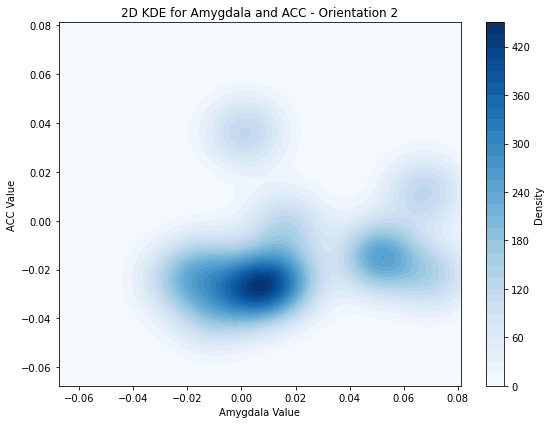

Orientation: 3


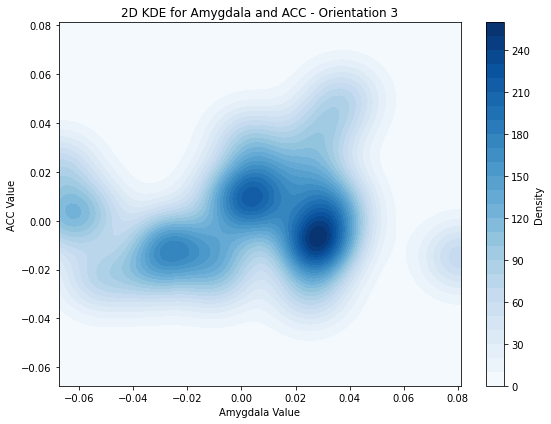

Orientation: 4


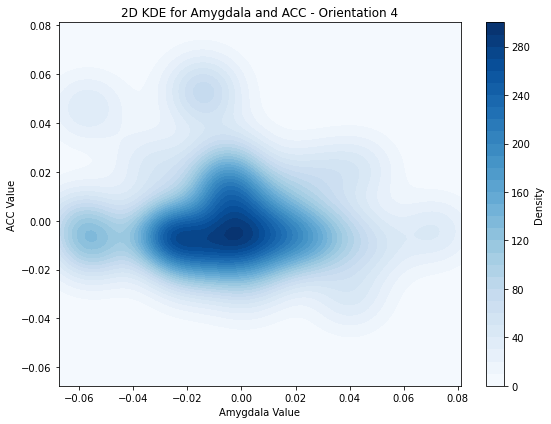

Orientation: 5


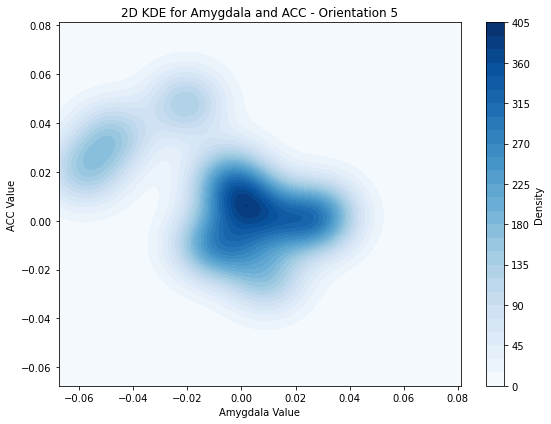

In [23]:
X_plot = np.linspace(df[['amygdala', 'acc']].min().min(), 
                     df[['amygdala', 'acc']].max().max(), 100)
Y_plot = np.linspace(df[['amygdala', 'acc']].min().min(), 
                     df[['amygdala', 'acc']].max().max(), 100)

# Create meshgrid from X_plot and Y_plot
X_plot, Y_plot = np.meshgrid(X_plot, Y_plot)
grid_points = np.vstack([X_plot.ravel(), Y_plot.ravel()]).T

for c in range(2, 6):
    print(f"Orientation: {c}")
    
    
    orient_data = df[df['orientation'] == c]
    amygdala = orient_data['amygdala'].values.reshape(-1, 1)
    acc = orient_data['acc'].values.reshape(-1, 1)
    
    #combining data
    data = np.hstack([amygdala, acc])

    # Perform 2D KDE
    kde = KernelDensity(kernel='gaussian', bandwidth=0.01)  
    kde.fit(data)

    # Estimate the density on the grid
    log_density = kde.score_samples(grid_points)
    density = np.exp(log_density).reshape(X_plot.shape)

    # 2D heatmap
    plt.figure(figsize=(8, 6))
    plt.contourf(X_plot, Y_plot, density, levels=30, cmap='Blues')
    plt.colorbar(label="Density")
    plt.title(f"2D KDE for Amygdala and ACC - Orientation {c}")
    plt.xlabel("Amygdala Value")
    plt.ylabel("ACC Value")
    
    # Apply tight layout before showing the plot
    plt.tight_layout()
    plt.show()
